In [6]:
import numpy as np
import scipy as sp
from scipy.special import j1
import time
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
from matplotlib import cm
from matplotlib.colors import LogNorm
from mpl_toolkits.mplot3d import axes3d
%pylab inline
figsize(11, 11)

from importlib.machinery import SourceFileLoader

#Paraxial_Equation = SourceFileLoader("Paraxial_Equation", "../source/Paraxial_Equation.py").load_module()
import sys
sys.path.append("../source/")
from Paraxial_Equation import Paraxial_Equation

import pickle

def errorCal(field,stepSizeX,stepSizeY):
    energy = np.trapz(np.trapz(np.abs(field)**2.0,dx=stepSizeX),dx=stepSizeY)
    return energy

def figsize(scale):
    fig_width_pt = 469.755                          # Get this from LaTeX using \the\textwidth
    inches_per_pt = 1.0/72.27                       # Convert pt to inch
    golden_mean = (np.sqrt(5.0)-1.0)/2.0            # Aesthetic ratio (you could change this)
    fig_width = fig_width_pt*inches_per_pt*scale    # width in inches
    fig_height = fig_width*golden_mean              # height in inches
    fig_size = [fig_width,fig_height]
    return fig_size

pgf_with_latex = {                      # setup matplotlib to use latex for output
    "pgf.texsystem": "pdflatex",        # change this if using xetex or lautex
    "text.usetex": True,                # use LaTeX to write all text
    "font.family": "serif",
    "font.serif": [],                   # blank entries should cause plots to inherit fonts from the document
    "font.sans-serif": [],
    "font.monospace": [],
    "axes.labelsize": 10,               # LaTeX default is 10pt font.
    "text.fontsize": 10,
    "legend.fontsize": 8,               # Make the legend/label fonts a little smaller
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.figsize": figsize(0.9),     # default fig size of 0.9 textwidth
    "pgf.preamble": [
        r"\usepackage[utf8x]{inputenc}",    # use utf8 fonts becasue your computer can handle it :)
        r"\usepackage[T1]{fontenc}",        # plots will be generated using this preamble
        r"\usepackage{gensymb}",
        r"\usepackage{amsmath,amssymb,amsfonts,fixmath}"
        ]
    }
mpl.rcParams.update(pgf_with_latex)


# I make my own newfig and savefig functions
def newfig(width):
    plt.clf()
    fig = plt.figure(figsize=figsize(width))
    ax = fig.add_subplot(111)
    return fig, ax

def savefig(filename):
    plt.savefig('{}.pgf'.format(filename))
    plt.savefig('{}.pdf'.format(filename))

Populating the interactive namespace from numpy and matplotlib


/home/dcargill/anaconda3/lib/python3.6/site-packages/matplotlib/__init__.py:800: MatplotlibDeprecationWarning: text.fontsize is deprecated and replaced with font.size; please use the latter.
  mplDeprecation)


In [7]:

## Define Dimensional Parameter Values
# codeName             # Value                   # (symbol) [char. value] <units>
#----------------------------------------------------------------------------------------------
waveLength             = 1e-6                    # (lambda) [10^{-6}]          <meters>
waveNumber             = (2.0*np.pi)/waveLength  # (lambda) [10^{6}]           <meters^{-1}>
innerScale             = 1e-2                    # (l_0)    [10^{-3}]          <meters>
outerScale             = 10                      # (L_0)    [10^{3}]           <meters>
indexStructureConstant = 5e-9                    # (C_n)    [10^{-10},10^{-6}] <meters^{-1/3}>
indexVarianceScaling   = 1                       # C_0
apertureDiameter       = 0.1                     # (D_{i})  [1 - .1]           <meters>
propagationDistance    = 5e2                     # (L)      [10^{3} - 10^{4}]  <meters> 
lengthX                = 0.5                     # XLength x_max               <meters>
lengthY                = 0.5                     # YLength y_max               <meters>
backgroundIndex        = 1.0 + 1e-6              # n_0      [1+e-6]

#alphaTarget = 5
#gamma2Target = 25
#gammaTarget  = np.sqrt(gamma2Target)
#transverseCharacteristicLength  = (2.0**(1/4) * gammaTarget) / (waveNumber * indexStructureConstant**(1/2) * outerScale**(1/6))
#propagationCharacteristicLength = (transverseCharacteristicLength**2.0) * waveNumber/alphaTarget

transverseCharacteristicLength  = innerScale
propagationCharacteristicLength = outerScale

## Define Dimensional Parameter Values
# codeName             # Value                   # (symbol) [char. value] <units>
#----------------------------------------------------------------------------------------------
numberOfPointsX                   = 128
numberOfPointsY                   = 128
#numberOfPointsZ                   = 64
#numberOfInformationBlocks         = 3
#numberOfZStepsPerInformationBlock = 6
initialFieldIdentifier            = 'const'
numberOfZPointsVector = np.array([np.power(2,index+6) for index in range(6)])


In [3]:
for index1 in range(6):
    
    #filename = 'SplitStep1FullApprox_numberOfPointsZ-'+str(numberOfZPointsVector[index1])+'.pkl'
    #filename = 'SplitStep1HalfApprox_numberOfPointsZ-'+str(numberOfZPointsVector[index1])+'.pkl'
    #filename = 'SplitStep1Exact_numberOfPointsZ-'+str(numberOfZPointsVector[index1])+'.pkl'
    
    #filename = 'SplitStep1FullApproxOrder2_numberOfPointsZ-'+str(numberOfZPointsVector[index1])+'.pkl'
    #filename = 'SplitStep1HalfApproxOrder2_numberOfPointsZ-'+str(numberOfZPointsVector[index1])+'.pkl'
    #filename = 'SplitStep1ExactOrder2_numberOfPointsZ-'+str(numberOfZPointsVector[index1])+'.pkl'
    
    #filename = 'SplitStep2FullApprox_numberOfPointsZ-'+str(numberOfZPointsVector[index1])+'.pkl'
    #filename = 'SplitStep2HalfApprox_numberOfPointsZ-'+str(numberOfZPointsVector[index1])+'.pkl'
    #filename = 'SplitStep2Exact_numberOfPointsZ-'+str(numberOfZPointsVector[index1])+'.pkl'

    #filename = 'SplitStep4Exact_numberOfPointsZ-'+str(numberOfZPointsVector[index1])+'.pkl'
    #filename = 'SplitStep4HalfApprox_numberOfPointsZ-'+str(numberOfZPointsVector[index1])+'.pkl'
    
    fileObject = open(filename, 'wb') 
    
    sim = Paraxial_Equation(waveLength,
                      innerScale,
                      outerScale,
                      indexStructureConstant,
                      indexVarianceScaling,
                      backgroundIndex, 
                      apertureDiameter,
                      lengthX, 
                      numberOfPointsX,
                      lengthY, 
                      numberOfPointsY,
                      propagationDistance,
                      numberOfZPointsVector[index1],
                      transverseCharacteristicLength,
                      propagationCharacteristicLength,                            
                      initialFieldIdentifier)

   

    
    #sim.SplitStep1FullApprox(numberOfZPointsVector[index1])
    #sim.SplitStep1HalfApprox(numberOfZPointsVector[index1])
    #sim.SplitStep1Exact(numberOfZPointsVector[index1])
    
    #sim.SplitStep2FullApprox(numberOfZPointsVector[index1])
    #sim.SplitStep2HalfApprox(numberOfZPointsVector[index1])
    sim.SplitStep2Exact(numberOfZPointsVector[index1])  
    
    
    #sim.SplitStep4Approx(numberOfZPointsVector[index1])
    #sim.SplitStep4Exact(numberOfZPointsVector[index1])    
    print('number ', numberOfZPointsVector[index1], ' done')
    
    pickle.dump([sim.stepSizeX,\
                 sim.meshPointsX,\
                 sim.stepSizeY, \
                 sim.meshPointsY, \
                 sim.recordedFieldFFTIntgrator[:,:,numberOfZPointsVector[index1]]], \
                fileObject, \
                pickle.HIGHEST_PROTOCOL)
    fileObject.close()

    del sim

innerScale: 0.01
outerScale: 10
indexStructureConstant: 5e-09
indexVarianceScaling: 1
backgroundIndex: 1.000001
apertureDiameter: 0.1
lengthX: 0.5
numberOfPointsX: 128
lengthY: 0.5
numberOfPointsY: 128
propagationDistance: 500.0
numberOfPointsZ: 64
initialFieldIdentifier: const
indexStandardDeviation: 7.61707689473e-09
epsilon: 0.001
alpha: 62.83185307179588
beta: 62831.85307179587
gamma: 5.48370442834
nu: 0.000478595056286
computationalApertureDiameter: 10.0
computationalPropagationDistance: 50.0
computationalLengthInZ: 50.0
stepSizeZ: 0.78125
computationalWidthX: 50.0
stepSizeX: 0.390625
computationalWidthY: 50.0
stepSizeY: 0.390625
Finshed step  1  of  64
FFT Energy:  0.988889965964
Finshed step  2  of  64
FFT Energy:  0.988889965176
Finshed step  3  of  64
FFT Energy:  0.988889963914
Finshed step  4  of  64
FFT Energy:  0.988889962255
Finshed step  5  of  64
FFT Energy:  0.9888899603
Finshed step  6  of  64
FFT Energy:  0.988889958171
Finshed step  7  of  64
FFT Energy:  0.98888995

Finshed step  125  of  128
FFT Energy:  0.988889952137
Finshed step  126  of  128
FFT Energy:  0.988889951489
Finshed step  127  of  128
FFT Energy:  0.988889950892
Finshed step  128  of  128
FFT Energy:  0.988889950361
number  128  done
innerScale: 0.01
outerScale: 10
indexStructureConstant: 5e-09
indexVarianceScaling: 1
backgroundIndex: 1.000001
apertureDiameter: 0.1
lengthX: 0.5
numberOfPointsX: 128
lengthY: 0.5
numberOfPointsY: 128
propagationDistance: 500.0
numberOfPointsZ: 256
initialFieldIdentifier: const
indexStandardDeviation: 7.61707689473e-09
epsilon: 0.001
alpha: 62.83185307179588
beta: 62831.85307179587
gamma: 5.48370442834
nu: 0.000478595056286
computationalApertureDiameter: 10.0
computationalPropagationDistance: 50.0
computationalLengthInZ: 50.0
stepSizeZ: 0.1953125
computationalWidthX: 50.0
stepSizeX: 0.390625
computationalWidthY: 50.0
stepSizeY: 0.390625
Finshed step  1  of  256
FFT Energy:  0.988889966216
Finshed step  2  of  256
FFT Energy:  0.988889966166
Finshed st

FFT Energy:  0.988889956056
Finshed step  180  of  256
FFT Energy:  0.988889955788
Finshed step  181  of  256
FFT Energy:  0.988889955519
Finshed step  182  of  256
FFT Energy:  0.98888995525
Finshed step  183  of  256
FFT Energy:  0.988889954984
Finshed step  184  of  256
FFT Energy:  0.988889954724
Finshed step  185  of  256
FFT Energy:  0.988889954473
Finshed step  186  of  256
FFT Energy:  0.988889954232
Finshed step  187  of  256
FFT Energy:  0.988889954004
Finshed step  188  of  256
FFT Energy:  0.988889953791
Finshed step  189  of  256
FFT Energy:  0.988889953595
Finshed step  190  of  256
FFT Energy:  0.988889953418
Finshed step  191  of  256
FFT Energy:  0.988889953261
Finshed step  192  of  256
FFT Energy:  0.988889953126
Finshed step  193  of  256
FFT Energy:  0.988889953015
Finshed step  194  of  256
FFT Energy:  0.988889952927
Finshed step  195  of  256
FFT Energy:  0.988889952864
Finshed step  196  of  256
FFT Energy:  0.988889952826
Finshed step  197  of  256
FFT Energy:

Finshed step  111  of  512
FFT Energy:  0.988889950005
Finshed step  112  of  512
FFT Energy:  0.988889950122
Finshed step  113  of  512
FFT Energy:  0.988889950248
Finshed step  114  of  512
FFT Energy:  0.988889950382
Finshed step  115  of  512
FFT Energy:  0.988889950524
Finshed step  116  of  512
FFT Energy:  0.988889950674
Finshed step  117  of  512
FFT Energy:  0.988889950831
Finshed step  118  of  512
FFT Energy:  0.988889950995
Finshed step  119  of  512
FFT Energy:  0.988889951167
Finshed step  120  of  512
FFT Energy:  0.988889951346
Finshed step  121  of  512
FFT Energy:  0.988889951532
Finshed step  122  of  512
FFT Energy:  0.988889951724
Finshed step  123  of  512
FFT Energy:  0.988889951922
Finshed step  124  of  512
FFT Energy:  0.988889952127
Finshed step  125  of  512
FFT Energy:  0.988889952338
Finshed step  126  of  512
FFT Energy:  0.988889952554
Finshed step  127  of  512
FFT Energy:  0.988889952775
Finshed step  128  of  512
FFT Energy:  0.988889953002
Finshed st

Finshed step  284  of  512
FFT Energy:  0.988889953765
Finshed step  285  of  512
FFT Energy:  0.988889953882
Finshed step  286  of  512
FFT Energy:  0.988889954002
Finshed step  287  of  512
FFT Energy:  0.988889954126
Finshed step  288  of  512
FFT Energy:  0.988889954253
Finshed step  289  of  512
FFT Energy:  0.988889954383
Finshed step  290  of  512
FFT Energy:  0.988889954516
Finshed step  291  of  512
FFT Energy:  0.988889954651
Finshed step  292  of  512
FFT Energy:  0.988889954788
Finshed step  293  of  512
FFT Energy:  0.988889954926
Finshed step  294  of  512
FFT Energy:  0.988889955066
Finshed step  295  of  512
FFT Energy:  0.988889955207
Finshed step  296  of  512
FFT Energy:  0.988889955348
Finshed step  297  of  512
FFT Energy:  0.988889955489
Finshed step  298  of  512
FFT Energy:  0.98888995563
Finshed step  299  of  512
FFT Energy:  0.988889955771
Finshed step  300  of  512
FFT Energy:  0.988889955911
Finshed step  301  of  512
FFT Energy:  0.98888995605
Finshed step

...

Finshed step  1335  of  2048
FFT Energy:  0.988889958302
Finshed step  1336  of  2048
FFT Energy:  0.988889958294
Finshed step  1337  of  2048
FFT Energy:  0.988889958286
Finshed step  1338  of  2048
FFT Energy:  0.988889958278
Finshed step  1339  of  2048
FFT Energy:  0.988889958269
Finshed step  1340  of  2048
FFT Energy:  0.98888995826
Finshed step  1341  of  2048
FFT Energy:  0.98888995825
Finshed step  1342  of  2048
FFT Energy:  0.98888995824
Finshed step  1343  of  2048
FFT Energy:  0.98888995823
Finshed step  1344  of  2048
FFT Energy:  0.988889958219
Finshed step  1345  of  2048
FFT Energy:  0.988889958208
Finshed step  1346  of  2048
FFT Energy:  0.988889958196
Finshed step  1347  of  2048
FFT Energy:  0.988889958184
Finshed step  1348  of  2048
FFT Energy:  0.988889958172
Finshed step  1349  of  2048
FFT Energy:  0.988889958159
Finshed step  1350  of  2048
FFT Energy:  0.988889958146
Finshed step  1351  of  2048
FFT Energy:  0.988889958133
Finshed step  1352  of  2048
FFT En

Finshed step  1497  of  2048
FFT Energy:  0.988889953981
Finshed step  1498  of  2048
FFT Energy:  0.988889953954
Finshed step  1499  of  2048
FFT Energy:  0.988889953927
Finshed step  1500  of  2048
FFT Energy:  0.9888899539
Finshed step  1501  of  2048
FFT Energy:  0.988889953873
Finshed step  1502  of  2048
FFT Energy:  0.988889953847
Finshed step  1503  of  2048
FFT Energy:  0.988889953821
Finshed step  1504  of  2048
FFT Energy:  0.988889953795
Finshed step  1505  of  2048
FFT Energy:  0.98888995377
Finshed step  1506  of  2048
FFT Energy:  0.988889953745
Finshed step  1507  of  2048
FFT Energy:  0.98888995372
Finshed step  1508  of  2048
FFT Energy:  0.988889953695
Finshed step  1509  of  2048
FFT Energy:  0.988889953671
Finshed step  1510  of  2048
FFT Energy:  0.988889953647
Finshed step  1511  of  2048
FFT Energy:  0.988889953623
Finshed step  1512  of  2048
FFT Energy:  0.9888899536
Finshed step  1513  of  2048
FFT Energy:  0.988889953576
Finshed step  1514  of  2048
FFT Ener

Finshed step  1662  of  2048
FFT Energy:  0.988889954152
Finshed step  1663  of  2048
FFT Energy:  0.98888995418
Finshed step  1664  of  2048
FFT Energy:  0.988889954208
Finshed step  1665  of  2048
FFT Energy:  0.988889954236
Finshed step  1666  of  2048
FFT Energy:  0.988889954264
Finshed step  1667  of  2048
FFT Energy:  0.988889954293
Finshed step  1668  of  2048
FFT Energy:  0.988889954321
Finshed step  1669  of  2048
FFT Energy:  0.98888995435
Finshed step  1670  of  2048
FFT Energy:  0.988889954379
Finshed step  1671  of  2048
FFT Energy:  0.988889954408
Finshed step  1672  of  2048
FFT Energy:  0.988889954437
Finshed step  1673  of  2048
FFT Energy:  0.988889954466
Finshed step  1674  of  2048
FFT Energy:  0.988889954496
Finshed step  1675  of  2048
FFT Energy:  0.988889954525
Finshed step  1676  of  2048
FFT Energy:  0.988889954555
Finshed step  1677  of  2048
FFT Energy:  0.988889954585
Finshed step  1678  of  2048
FFT Energy:  0.988889954615
Finshed step  1679  of  2048
FFT 

Finshed step  1826  of  2048
FFT Energy:  0.988889957634
Finshed step  1827  of  2048
FFT Energy:  0.988889957631
Finshed step  1828  of  2048
FFT Energy:  0.988889957627
Finshed step  1829  of  2048
FFT Energy:  0.988889957622
Finshed step  1830  of  2048
FFT Energy:  0.988889957618
Finshed step  1831  of  2048
FFT Energy:  0.988889957613
Finshed step  1832  of  2048
FFT Energy:  0.988889957607
Finshed step  1833  of  2048
FFT Energy:  0.988889957601
Finshed step  1834  of  2048
FFT Energy:  0.988889957595
Finshed step  1835  of  2048
FFT Energy:  0.988889957588
Finshed step  1836  of  2048
FFT Energy:  0.98888995758
Finshed step  1837  of  2048
FFT Energy:  0.988889957573
Finshed step  1838  of  2048
FFT Energy:  0.988889957564
Finshed step  1839  of  2048
FFT Energy:  0.988889957556
Finshed step  1840  of  2048
FFT Energy:  0.988889957547
Finshed step  1841  of  2048
FFT Energy:  0.988889957537
Finshed step  1842  of  2048
FFT Energy:  0.988889957527
Finshed step  1843  of  2048
FFT

Finshed step  1992  of  2048
FFT Energy:  0.988889952493
Finshed step  1993  of  2048
FFT Energy:  0.98888995245
Finshed step  1994  of  2048
FFT Energy:  0.988889952408
Finshed step  1995  of  2048
FFT Energy:  0.988889952365
Finshed step  1996  of  2048
FFT Energy:  0.988889952323
Finshed step  1997  of  2048
FFT Energy:  0.988889952281
Finshed step  1998  of  2048
FFT Energy:  0.988889952239
Finshed step  1999  of  2048
FFT Energy:  0.988889952197
Finshed step  2000  of  2048
FFT Energy:  0.988889952155
Finshed step  2001  of  2048
FFT Energy:  0.988889952113
Finshed step  2002  of  2048
FFT Energy:  0.988889952072
Finshed step  2003  of  2048
FFT Energy:  0.988889952031
Finshed step  2004  of  2048
FFT Energy:  0.988889951989
Finshed step  2005  of  2048
FFT Energy:  0.988889951948
Finshed step  2006  of  2048
FFT Energy:  0.988889951907
Finshed step  2007  of  2048
FFT Energy:  0.988889951867
Finshed step  2008  of  2048
FFT Energy:  0.988889951826
Finshed step  2009  of  2048
FFT

In [ ]:
SplitStep4Exact_errorVector = np.zeros(4)
SplitStep4Exact_recordedField = np.empty([numberOfPointsX,numberOfPointsY,4], dtype=np.complex128)

for index1 in range(4):
    
    filename = 'SplitStep4Exact_numberOfPointsZ-'+str(numberOfZPointsVector[index1])+'.pkl'
    fileObject = open(filename, 'rb') 
    [stepSizeX, \
     meshPointsX,\
     stepSizeY, \
     meshPointsY, \
     SplitStep4Exact_recordedField[:,:,index1]] = pickle.load(fileObject)
    
    fileObject.close()
    
exact = SplitStep4Exact_recordedField[:,:,-1]
for index1 in range(4):
    SplitStep4Exact_errorVector[index1] = errorCal(SplitStep4Exact_recordedField[:,:,index1]-exact,\
                                                   stepSizeX,\
                                                   stepSizeY)

In [ ]:
SplitStep4HalfApprox_errorVector = np.zeros(3)
SplitStep4HalfApprox_recordedField = np.empty([numberOfPointsX,numberOfPointsY,3], dtype=np.complex128)

for index1 in range(3):
    
    filename = 'SplitStep4HalfApprox_numberOfPointsZ-'+str(numberOfZPointsVector[index1])+'.pkl'
    fileObject = open(filename, 'rb') 
    [stepSizeX, \
     meshPointsX,\
     stepSizeY, \
     meshPointsY, \
     SplitStep4HalfApprox_recordedField[:,:,index1]] = pickle.load(fileObject)
    
    fileObject.close()
    
exact = SplitStep4HalfApprox_recordedField[:,:,-1]
for index1 in range(3):
    SplitStep4HalfApprox_errorVector[index1] = errorCal(SplitStep4HalfApprox_recordedField[:,:,index1]-exact,\
                                                   stepSizeX,\
                                                   stepSizeY)

In [ ]:
SplitStep1FullApproxOrder2_errorVector = np.zeros(6)
SplitStep1FullApproxOrder2_recordedField = np.empty([numberOfPointsX,numberOfPointsY,6], dtype=np.complex128)

for index1 in range(6):
    
    filename = 'SplitStep1FullApproxOrder2_numberOfPointsZ-'+str(numberOfZPointsVector[index1])+'.pkl'
    fileObject = open(filename, 'rb') 
    [stepSizeX, \
     meshPointsX,\
     stepSizeY, \
     meshPointsY, \
     SplitStep1FullApproxOrder2_recordedField[:,:,index1]] = pickle.load(fileObject)
    
    fileObject.close()
    
exact = SplitStep1FullApproxOrder2_recordedField[:,:,-1]
for index1 in range(6):
    SplitStep1FullApproxOrder2_errorVector[index1] = errorCal(SplitStep1FullApproxOrder2_recordedField[:,:,index1]-exact,\
                                                        stepSizeX,\
                                                        stepSizeY)

In [ ]:
SplitStep1HalfApproxOrder2_errorVector = np.zeros(6)
SplitStep1HalfApproxOrder2_recordedField = np.empty([numberOfPointsX,numberOfPointsY,6], dtype=np.complex128)

for index1 in range(6):
    
    filename = 'SplitStep1HalfApproxOrder2_numberOfPointsZ-'+str(numberOfZPointsVector[index1])+'.pkl'
    fileObject = open(filename, 'rb') 
    [stepSizeX, \
     meshPointsX,\
     stepSizeY, \
     meshPointsY, \
     SplitStep1HalfApproxOrder2_recordedField[:,:,index1]] = pickle.load(fileObject)
    
    fileObject.close()
    
exact = SplitStep1HalfApproxOrder2_recordedField[:,:,5]
for index1 in range(6):
    SplitStep1HalfApproxOrder2_errorVector[index1] = errorCal(SplitStep1HalfApproxOrder2_recordedField[:,:,index1]-exact,\
                                                        stepSizeX,\
                                                        stepSizeY)



In [ ]:
SplitStep1ExactOrder2_errorVector = np.zeros(6)
SplitStep1ExactOrder2_recordedField = np.empty([numberOfPointsX,numberOfPointsY,6], dtype=np.complex128)

for index1 in range(6):
    
    filename = 'SplitStep1ExactOrder2_numberOfPointsZ-'+str(numberOfZPointsVector[index1])+'.pkl'
    fileObject = open(filename, 'rb') 
    [stepSizeX, \
     meshPointsX,\
     stepSizeX, \
     meshPointsY, \
     SplitStep1ExactOrder2_recordedField[:,:,index1]] = pickle.load(fileObject)
    
    fileObject.close()
    
exact = SplitStep1ExactOrder2_recordedField[:,:,5]
for index1 in range(6):    
    SplitStep1ExactOrder2_errorVector[index1] = errorCal(SplitStep1ExactOrder2_recordedField[:,:,index1]-exact,\
                                                        stepSizeX,\
                                                        stepSizeY)


In [ ]:
SplitStep1FullApprox_errorVector

In [ ]:
SplitStep1HalfApprox_errorVector

In [ ]:
SplitStep1Exact_errorVector

In [ ]:
fig, ax1  = newfig(0.6)
 

#ax1.set_xticks(np.arange(0, 101, 5), minor=True)    

  
#labels = [item.get_text() for item in ax1.get_yticklabels()]
#labels[3] = '$\mathbold{L_0}^{\mathbold{2/3}}$'
#ax1.set_yticklabels(labels)
#ax1.set_yticks(np.arange(0, 101, 5), minor=True) 
#ax1.set_yticks(np.arange(0, 101, 5), minor=True)                                                            

# or if you want differnet settings for the grids:                               
#ax.grid(which='minor', alpha=0.2)                                                

ax1.tick_params(axis='x',which='minor',bottom='off',top='off')
ax1.tick_params(axis='y',which='minor',right='off',left='off')
ax1.tick_params(direction='in')


#ax1.set_title('Kolmogorov Tubulence Structure Function')
ax1.set_xlabel('Number of $Z$ Points')
ax1.set_ylabel('Error')


#format_axes(ax1)
ax1.loglog(numberOfZPointsVector,SplitStep1FullApproxOrder2_errorVector/SplitStep1FullApproxOrder2_errorVector[0],'or')
ax1.loglog(numberOfZPointsVector,SplitStep1HalfApproxOrder2_errorVector/SplitStep1HalfApproxOrder2_errorVector[0],'+r')
ax1.loglog(numberOfZPointsVector,SplitStep1ExactOrder2_errorVector/SplitStep1ExactOrder2_errorVector[0],'*r')

#loglog(10/numberOfZPointsVector,10000000000*(10/numberOfZPointsVector)**5.0,'r')
vector = 1.0/numberOfZPointsVector
ax1.loglog(numberOfZPointsVector,(vector/vector[0])**1.0,'r')
ax1.loglog(numberOfZPointsVector,(vector/vector[0])**1.5,'--r')
ax1.loglog(numberOfZPointsVector,(vector/vector[0])**2.0,'g')
ax1.loglog(numberOfZPointsVector,(vector/vector[0])**2.5,'--g')
ax1.loglog(numberOfZPointsVector,(vector/vector[0])**3.0,'b')
ax1.loglog(numberOfZPointsVector,(vector/vector[0])**3.5,'--b')
ax1.loglog(numberOfZPointsVector,(vector/vector[0])**4.0,'k')

ax1.set_ylim([1e-7,10])
ax1.set_yticks([1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1,10]) 


ax1.set_xticklabels(["256","512","1024","2048","4096","8192"])
ax1.set_xticks([256,512,1024,2048,4096,8192])  



fig.tight_layout()
savefig('convergence')

In [ ]:
SplitStep2FullApprox_errorVector = np.zeros(6)
SplitStep2FullApprox_recordedField = np.empty([numberOfPointsX,numberOfPointsY,6], dtype=np.complex128)

for index1 in range(6):
    
    filename = 'SplitStep2FullApprox_numberOfPointsZ-'+str(numberOfZPointsVector[index1])+'.pkl'
    fileObject = open(filename, 'rb') 
    [stepSizeX, \
     meshPointsX,\
     stepSizeY, \
     meshPointsY, \
     SplitStep2FullApprox_recordedField[:,:,index1]] = pickle.load(fileObject)
    
    fileObject.close()
    
exact = SplitStep2FullApprox_recordedField[:,:,-1]
for index1 in range(6):    
    SplitStep2FullApprox_errorVector[index1] = errorCal(SplitStep2FullApprox_recordedField[:,:,index1]-exact,\
                                                        stepSizeX,\
                                                        stepSizeY)

In [ ]:
SplitStep2HalfApprox_errorVector = np.zeros(6)
SplitStep2HalfApprox_recordedField = np.empty([numberOfPointsX,numberOfPointsY,6], dtype=np.complex128)

for index1 in range(6):
    
    filename = 'SplitStep2HalfApprox_numberOfPointsZ-'+str(numberOfZPointsVector[index1])+'.pkl'
    fileObject = open(filename, 'rb') 
    [stepSizeX, \
     meshPointsX,\
     stepSizeY, \
     meshPointsY, \
     SplitStep2HalfApprox_recordedField[:,:,index1]] = pickle.load(fileObject)
    
    fileObject.close()
    
exact = SplitStep2HalfApprox_recordedField[:,:,-1]
for index1 in range(6):    
    SplitStep2HalfApprox_errorVector[index1] = errorCal(SplitStep2HalfApprox_recordedField[:,:,index1]-exact,\
                                                        stepSizeX,\
                                                        stepSizeY) 

In [4]:
SplitStep2Exact_errorVector = np.zeros(6)
SplitStep2Exact_recordedField = np.empty([numberOfPointsX,numberOfPointsY,6], dtype=np.complex128)

for index1 in range(6):
    
    filename = 'SplitStep2Exact_numberOfPointsZ-'+str(numberOfZPointsVector[index1])+'.pkl'
    fileObject = open(filename, 'rb') 
    [stepSizeX, \
     meshPointsX,\
     stepSizeY, \
     meshPointsY, \
     SplitStep2Exact_recordedField[:,:,index1]] = pickle.load(fileObject)
    
    fileObject.close()
    
exact = SplitStep2Exact_recordedField[:,:,-1]
for index1 in range(6):    
    SplitStep2Exact_errorVector[index1] = errorCal(SplitStep2Exact_recordedField[:,:,index1]-exact,\
                                                        stepSizeX,\
                                                        stepSizeY)

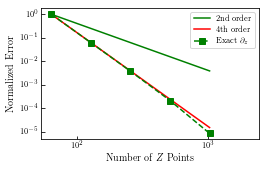

In [6]:
fig, ax1  = newfig(0.6)
 

#ax1.set_xticks(np.arange(0, 101, 5), minor=True)    

  
#labels = [item.get_text() for item in ax1.get_yticklabels()]
#labels[3] = '$\mathbold{L_0}^{\mathbold{2/3}}$'
#ax1.set_yticklabels(labels)
#ax1.set_yticks(np.arange(0, 101, 5), minor=True) 
#ax1.set_yticks(np.arange(0, 101, 5), minor=True)                                                            

# or if you want differnet settings for the grids:                               
#ax.grid(which='minor', alpha=0.2)                                                

ax1.tick_params(axis='x',which='minor',bottom='off',top='off')
ax1.tick_params(axis='y',which='minor',right='off',left='off')
ax1.tick_params(direction='in')


#ax1.set_title('Kolmogorov Tubulence Structure Function')
ax1.set_xlabel('Number of $Z$ Points')
ax1.set_ylabel('Normalized Error')


#format_axes(ax1)
#ax1.loglog(numberOfZPointsVector,SplitStep1FullApprox_errorVector/SplitStep1FullApprox_errorVector[0],'or')
#ax1.loglog(numberOfZPointsVector,SplitStep1HalfApprox_errorVector/SplitStep1HalfApprox_errorVector[0],'+r')
#ax1.loglog(numberOfZPointsVector,SplitStep1Exact_errorVector/SplitStep1Exact_errorVector[0],'*r')


xVector = numberOfZPointsVector[0:5]
vector = 1.0/xVector
#ax1.loglog(xVector,(vector/vector[0])**1.0,'r',label='1st order')
#ax1.loglog(xVector,(vector/vector[0])**1.5,'--r')
ax1.loglog(xVector,(vector/vector[0])**2.0,'g',label='2nd order')
#ax1.loglog(xVector,(vector/vector[0])**2.5,'--g')
#ax1.loglog(xVector,(vector/vector[0])**3.0,'b',label='3rd order')
#ax1.loglog(xVector,(vector/vector[0])**3.5,'--b')
ax1.loglog(xVector,(vector/vector[0])**4.0,'r',label='4th order')


#ax1.loglog(numberOfZPointsVector,SplitStep2FullApprox_errorVector/SplitStep2FullApprox_errorVector[0],'og')
#ax1.loglog(numberOfZPointsVector,SplitStep2HalfApprox_errorVector/SplitStep2HalfApprox_errorVector[0],'--og', label='Approximate $\partial_z$')
ax1.loglog(numberOfZPointsVector,SplitStep2Exact_errorVector/SplitStep2Exact_errorVector[0],'--sg',label='Exact $\partial_z$')
#ax1.loglog(numberOfZPointsVector,SplitStep4Exact_errorVector/SplitStep4Exact_errorVector[0],'--sg',label='Exact $\partial_z$')

#ax1.loglog(numberOfZPointsVector,SplitStep4HalfApprox_errorVector/SplitStep4HalfApprox_errorVector[0],'--sg',label='Exact $\partial_z$')


#ax1.set_ylim([1e-6,2])
#ax1.set_yticks([1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1]) 

#ax1.set_xlim([200,4600])
#ax1.set_xticklabels(["256","512","1024","2048","4096"])
#ax1.set_xticks([256,512,1024,2048,4096])  

plt.legend()

#fig.tight_layout()
savefig('convergence4')

In [ ]:
fig = plt.figure()
ax = fig.gca()
cont = ax.contourf(sim.meshPointsX, sim.meshWaveNumbersY, np.abs(sim.IndexOfRefractionFunction()),100,
                               linewidth=0, antialiased=False)
fig.colorbar(cont, shrink=0.5, aspect=5)
plt.show()

In [ ]:
loglog(10/numberOfZPointsVector,errorVector,'--')
hold 
loglog(10/numberOfZPointsVector,.0000000001*(10/numberOfZPointsVector)**5.0,'r')
loglog(10/numberOfZPointsVector,.00000000001*(10/numberOfZPointsVector)**4.0,'b')
loglog(10/numberOfZPointsVector,.000000000001*(10/numberOfZPointsVector)**3.0,'g')
loglog(10/numberOfZPointsVector,.0000000000001*(10/numberOfZPointsVector)**2.0,'k')

In [ ]:
loglog(numberOfZPointsVector,errorVector,'--')
hold 
#loglog(10/numberOfZPointsVector,10000000000*(10/numberOfZPointsVector)**5.0,'r')
loglog(numberOfZPointsVector,10000*(10/numberOfZPointsVector)**4.0,'b')
#loglog(10/numberOfZPointsVector,100000000*(10/numberOfZPointsVector)**3.0,'g')
loglog(numberOfZPointsVector,100*(10/numberOfZPointsVector)**2.0,'k')

In [ ]:
(2.0 + 2.0**(1/3) + 2.0**(-1/3))/3.0


In [ ]:
1.0-(2*(2.0 + 2.0**(1/3) + 2.0**(-1/3))/3.0)

In [ ]:
2**(1/3)